# RetainIQ — Phase 6.3: Geospatial Risk Patterns & Segment Geography

I will connect the Phase 5 customer segments to geography, profile segment mix across markets, calculate segment-level retention risk, and create a geographic grid view for spatial concentration.

## Interpretation rule

I will treat segment × geography patterns as descriptive. A location with higher churn inside a segment is a market pattern, not evidence that the location itself causes churn.

In [1]:
from getpass import getpass
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq",
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        rows = cursor.fetchall()
        return pd.DataFrame(rows)
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

def print_result(message):
    print(f"Result: {message}")


## 1. Load geography and Phase 5 segment assignments

In [2]:
query = """
SELECT
    f.customer_id,
    f.churn_label,
    f.total_revenue,
    f.cltv,
    f.satisfaction_score,
    l.state,
    l.city,
    l.zip_code,
    l.latitude,
    l.longitude,
    l.population,
    cs.segment_id,
    cs.segment_name
FROM fact_customer_status f
JOIN dim_location l
    ON f.customer_id = l.customer_id
JOIN customer_segment_assignments cs
    ON f.customer_id = cs.customer_id;
"""

geo_segment_df = run_query(query)
for column in [
    "total_revenue", "cltv", "satisfaction_score",
    "zip_code", "latitude", "longitude", "population"
]:
    geo_segment_df[column] = pd.to_numeric(geo_segment_df[column], errors="coerce")

print_result(f"I loaded {len(geo_segment_df):,} geography + segment records.")
display(geo_segment_df.head())

Result: I loaded 7,043 geography + segment records.


,customer_id,churn_label,total_revenue,cltv,satisfaction_score,state,city,zip_code,latitude,longitude,population,segment_id,segment_name
0,0002-ORFBO,No,974.81,2205,3,California,Frazier Park,93225,34.83,-119.00,4498,0,Segment 0 — Emerging Risk
1,0003-MKNFE,No,610.28,5414,5,California,Glendale,91206,34.16,-118.20,31297,0,Segment 0 — Emerging Risk
2,0004-TLHLJ,Yes,415.45,4479,1,California,Costa Mesa,92627,33.65,-117.92,62069,0,Segment 0 — Emerging Risk
3,0011-IGKFF,Yes,"1,599.51",3714,1,California,Martinez,94553,38.01,-122.12,46677,0,Segment 0 — Emerging Risk
4,0013-EXCHZ,Yes,289.54,3464,1,California,Camarillo,93010,34.23,-119.08,42853,0,Segment 0 — Emerging Risk


### Result & conclusion

The Phase 5 segment label is now available beside the geographic fields. This lets me ask which segments are concentrated in which markets and where segment-level retention risk is most visible.

## 2. Validate segment coverage

In [3]:
assert len(geo_segment_df) == 7043
assert geo_segment_df["customer_id"].nunique() == 7043
assert geo_segment_df["customer_id"].is_unique
assert geo_segment_df["segment_id"].notna().all()

segment_count = geo_segment_df["segment_name"].nunique(dropna=True)
print_result(f"I confirmed one row per customer and {segment_count:,} populated customer segments.")

Result: I confirmed one row per customer and 3 populated customer segments.


### Result & conclusion

The geography-to-segment join is complete at customer grain. I can aggregate by state, city, and segment without introducing duplicate customers.

## 3. Segment mix by state

In [4]:
state_segment_mix = pd.crosstab(
    geo_segment_df["state"],
    geo_segment_df["segment_name"],
    normalize="index"
).mul(100).round(2)

display(state_segment_mix)
state_segment_mix.to_csv(Path("../outputs") / "state_segment_mix.csv")
print_result("The table shows each state's segment composition as a percentage of its own customer base.")

segment_name,Segment 0 — Emerging Risk,Segment 1 — High-Value Stable,Segment 2 — High-Value At-Risk
state,,,
California,45.80,22.11,32.09


Result: The table shows each state's segment composition as a percentage of its own customer base.


### Result & conclusion

The state segment mix shows whether the customer portfolio composition differs geographically. I can use this to distinguish a high-churn market caused by segment mix from a pattern that appears within a specific segment.

## 4. Segment distribution by city

In [5]:
city_segment_counts = (
    geo_segment_df.groupby(["state", "city", "segment_name"], dropna=False)
    .size()
    .rename("customers")
    .reset_index()
)

display(city_segment_counts.sort_values("customers", ascending=False).head(20))
print_result(f"I produced {len(city_segment_counts):,} city-segment combinations before filtering for focused risk analysis.")

,state,city,segment_name,customers
2068,California,San Diego,Segment 0 — Emerging Risk,189
1333,California,Los Angeles,Segment 0 — Emerging Risk,139
1335,California,Los Angeles,Segment 2 — High-Value At-Risk,83
1334,California,Los Angeles,Segment 1 — High-Value Stable,71
2070,California,San Diego,Segment 2 — High-Value At-Risk,68
2090,California,San Jose,Segment 0 — Emerging Risk,62
2030,California,Sacramento,Segment 0 — Emerging Risk,45
2076,California,San Francisco,Segment 0 — Emerging Risk,44
2032,California,Sacramento,Segment 2 — High-Value At-Risk,35
2092,California,San Jose,Segment 2 — High-Value At-Risk,32


Result: I produced 2,690 city-segment combinations before filtering for focused risk analysis.


### Result & conclusion

This table identifies where each segment is concentrated. Large segment populations matter because they provide a bigger base for retention actions and analysis.

## 5. Build the segment × market retention profile

In [6]:
segment_market = (
    geo_segment_df.groupby(["state", "city", "segment_name"], dropna=False)
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churn_label", lambda s: (s == "Yes").sum()),
        avg_cltv=("cltv", "mean"),
        revenue=("total_revenue", "sum")
    )
    .reset_index()
)

segment_market["churn_rate_pct"] = (
    segment_market["churned_customers"] /
    segment_market["customers"] * 100
)

risk_proxy = (
    geo_segment_df.loc[geo_segment_df["churn_label"] == "Yes"]
    .groupby(["state", "city", "segment_name"])["total_revenue"]
    .sum()
    .rename("revenue_at_risk")
    .reset_index()
)

segment_market = segment_market.merge(
    risk_proxy,
    on=["state", "city", "segment_name"],
    how="left"
)
segment_market["revenue_at_risk"] = segment_market["revenue_at_risk"].fillna(0)
segment_market = segment_market.round(2)

display(segment_market.head(20))
print_result(f"I created {len(segment_market):,} segment-market profiles and calculated a historical revenue exposure proxy for each one.")

,state,city,segment_name,customers,churned_customers,avg_cltv,revenue,churn_rate_pct,revenue_at_risk
0,California,Acampo,Segment 0 — Emerging Risk,2,2,"4,898.00","2,804.30",100.00,"2,804.30"
1,California,Acampo,Segment 2 — High-Value At-Risk,2,1,"5,611.00","15,303.66",50.00,"7,667.06"
2,California,Acton,Segment 0 — Emerging Risk,2,0,"4,509.00","2,977.60",0.00,0.00
3,California,Acton,Segment 2 — High-Value At-Risk,2,0,"4,913.00","9,178.76",0.00,0.00
4,California,Adelanto,Segment 0 — Emerging Risk,2,0,"3,863.00","3,398.17",0.00,0.00
5,California,Adelanto,Segment 1 — High-Value Stable,2,1,"4,812.00","5,128.63",50.00,"4,005.02"
6,California,Adelanto,Segment 2 — High-Value At-Risk,1,0,"4,474.00","9,708.69",0.00,0.00
7,California,Adin,Segment 0 — Emerging Risk,3,2,"3,723.67","3,094.40",66.67,"2,457.91"
8,California,Adin,Segment 1 — High-Value Stable,1,0,"4,791.00","2,444.98",0.00,0.00
9,California,Agoura Hills,Segment 0 — Emerging Risk,3,1,"4,797.33",306.24,33.33,124.89


Result: I created 2,690 segment-market profiles and calculated a historical revenue exposure proxy for each one.


### Result & conclusion

The segment × market profile combines customer count, churn rate, CLTV, and revenue exposure. This is the most useful table for identifying a specific segment within a specific market rather than treating the whole market as one group.

## 6. Filter for adequately sized market-segment groups

In [7]:
minimum_segment_market_size = 10
market_segment_risk = (
    segment_market[segment_market["customers"] >= minimum_segment_market_size]
    .sort_values("revenue_at_risk", ascending=False)
    .copy()
)

top_row = market_segment_risk.iloc[0]
print_result(
    f"I retained {len(market_segment_risk):,} market-segment groups with at least {minimum_segment_market_size} customers. The largest revenue-exposure group is {top_row['state']} / {top_row['city']} / {top_row['segment_name']}."
)
display(market_segment_risk.head(25))

Result: I retained 61 market-segment groups with at least 10 customers. The largest revenue-exposure group is California / San Diego / Segment 0 — Emerging Risk.


,state,city,segment_name,customers,churned_customers,avg_cltv,revenue,churn_rate_pct,revenue_at_risk
2068,California,San Diego,Segment 0 — Emerging Risk,189,150,"4,072.15","275,442.14",79.37,"209,313.94"
2070,California,San Diego,Segment 2 — High-Value At-Risk,68,24,"5,092.96","439,843.33",35.29,"174,128.19"
1333,California,Los Angeles,Segment 0 — Emerging Risk,139,67,"4,032.95","198,085.45",48.20,"91,118.74"
1335,California,Los Angeles,Segment 2 — High-Value At-Risk,83,8,"4,966.60","556,663.57",9.64,"55,755.85"
2076,California,San Francisco,Segment 0 — Emerging Risk,44,27,"4,159.91","66,159.63",61.36,"38,371.37"
2030,California,Sacramento,Segment 0 — Emerging Risk,45,21,"4,094.33","82,539.51",46.67,"38,092.87"
2399,California,Temecula,Segment 0 — Emerging Risk,22,19,"4,149.73","31,339.17",86.36,"30,239.50"
2090,California,San Jose,Segment 0 — Emerging Risk,62,24,"3,902.00","96,386.15",38.71,"22,291.85"
758,California,Fallbrook,Segment 0 — Emerging Risk,30,22,"4,311.83","34,741.60",73.33,"21,957.77"
734,California,Escondido,Segment 0 — Emerging Risk,26,14,"4,058.85","36,791.01",53.85,"21,837.63"


### Result & conclusion

The size rule avoids over-interpreting very small segment-market groups. The resulting table is a focused list of combinations with enough observations for practical comparison.

## 7. Build the geographic grid profile

In [8]:
valid_geo = geo_segment_df[
    geo_segment_df["latitude"].between(-90, 90, inclusive="both")
    & geo_segment_df["longitude"].between(-180, 180, inclusive="both")
].copy()

grid_precision = 2
valid_geo["lat_grid"] = valid_geo["latitude"].round(grid_precision)
valid_geo["lon_grid"] = valid_geo["longitude"].round(grid_precision)

grid_profile = (
    valid_geo.groupby(["lat_grid", "lon_grid"])
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churn_label", lambda s: (s == "Yes").sum()),
        avg_cltv=("cltv", "mean"),
        revenue=("total_revenue", "sum")
    )
    .reset_index()
)

grid_profile["churn_rate_pct"] = (
    grid_profile["churned_customers"] /
    grid_profile["customers"] * 100
)

grid_risk = (
    valid_geo.loc[valid_geo["churn_label"] == "Yes"]
    .groupby(["lat_grid", "lon_grid"])["total_revenue"]
    .sum()
    .rename("revenue_at_risk")
    .reset_index()
)

grid_profile = grid_profile.merge(
    grid_risk,
    on=["lat_grid", "lon_grid"],
    how="left"
)
grid_profile["revenue_at_risk"] = grid_profile["revenue_at_risk"].fillna(0)
grid_profile = grid_profile.round(2)

display(grid_profile.sort_values("revenue_at_risk", ascending=False).head(20))
print_result(f"I created {len(grid_profile):,} geographic grid cells from {len(valid_geo):,} customers with valid coordinates.")

,lat_grid,lon_grid,customers,churned_customers,avg_cltv,revenue,churn_rate_pct,revenue_at_risk
59,32.86,-117.21,36,33,"3,915.17","74,052.78",91.67,"73,064.56"
51,32.83,-117.20,34,30,"4,501.09","79,483.33",88.24,"66,875.02"
62,32.89,-117.15,32,28,"4,512.31","77,047.67",87.50,"56,705.51"
68,32.96,-117.20,22,20,"4,473.14","58,251.59",90.91,"51,348.08"
41,32.79,-117.23,27,24,"4,073.56","56,874.27",88.89,"45,052.15"
86,33.14,-116.97,38,15,"4,297.00","121,684.46",39.47,"38,796.10"
107,33.36,-117.30,43,26,"4,531.28","93,409.28",60.47,"34,691.78"
116,33.51,-117.03,30,18,"4,353.80","79,604.44",60.00,"34,069.04"
69,32.96,-117.13,16,15,"3,923.56","35,295.82",93.75,"33,770.47"
444,34.10,-118.33,6,5,"4,904.17","30,003.28",83.33,"22,788.79"


Result: I created 1,624 geographic grid cells from 7,043 customers with valid coordinates.


### Result & conclusion

The grid calculation aggregates nearby coordinates into rounded cells. I use it to visualize geographic concentration and observed churn intensity while avoiding false precision from individual latitude/longitude points.

## 8. Plot geographic concentration and churn

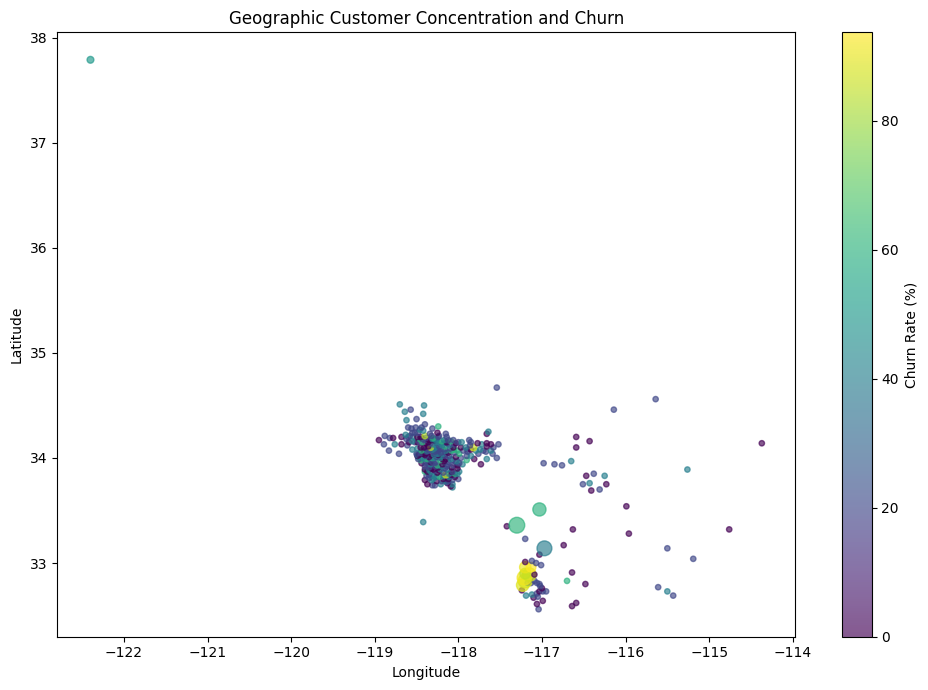

Result: The chart displays 347 grid cells with at least five customers; point size represents customer count and point color represents churn rate.


In [9]:
plot_data = grid_profile[grid_profile["customers"] >= 5].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    plot_data["lon_grid"],
    plot_data["lat_grid"],
    s=plot_data["customers"] * 3,
    c=plot_data["churn_rate_pct"],
    alpha=0.65
)
ax.set_title("Geographic Customer Concentration and Churn")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(scatter, ax=ax, label="Churn Rate (%)")
plt.tight_layout()
plt.show()

print_result(
    f"The chart displays {len(plot_data):,} grid cells with at least five customers; point size represents customer count and point color represents churn rate."
)

### Result & conclusion

This chart helps me see where customer density and observed churn overlap. It is an exploratory spatial view, not a causal model and not a forecast.

## 9. Create a focused priority market-segment table

In [10]:
priority_market_segments = market_segment_risk[[
    "state", "city", "segment_name", "customers",
    "churned_customers", "avg_cltv", "churn_rate_pct", "revenue_at_risk"
]].head(25).copy()

display(priority_market_segments)
print_result(
    f"I isolated the top {len(priority_market_segments):,} market-segment combinations ranked by the historical revenue exposure proxy."
)

,state,city,segment_name,customers,churned_customers,avg_cltv,churn_rate_pct,revenue_at_risk
2068,California,San Diego,Segment 0 — Emerging Risk,189,150,"4,072.15",79.37,"209,313.94"
2070,California,San Diego,Segment 2 — High-Value At-Risk,68,24,"5,092.96",35.29,"174,128.19"
1333,California,Los Angeles,Segment 0 — Emerging Risk,139,67,"4,032.95",48.20,"91,118.74"
1335,California,Los Angeles,Segment 2 — High-Value At-Risk,83,8,"4,966.60",9.64,"55,755.85"
2076,California,San Francisco,Segment 0 — Emerging Risk,44,27,"4,159.91",61.36,"38,371.37"
2030,California,Sacramento,Segment 0 — Emerging Risk,45,21,"4,094.33",46.67,"38,092.87"
2399,California,Temecula,Segment 0 — Emerging Risk,22,19,"4,149.73",86.36,"30,239.50"
2090,California,San Jose,Segment 0 — Emerging Risk,62,24,"3,902.00",38.71,"22,291.85"
758,California,Fallbrook,Segment 0 — Emerging Risk,30,22,"4,311.83",73.33,"21,957.77"
734,California,Escondido,Segment 0 — Emerging Risk,26,14,"4,058.85",53.85,"21,837.63"


Result: I isolated the top 25 market-segment combinations ranked by the historical revenue exposure proxy.


### Result & conclusion

This is the bridge from analysis to the Phase 7 strategy layer: I now have a concrete set of geographic segment combinations to examine alongside retention actions.

## 10. Export Phase 6.3 outputs

In [11]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

state_segment_mix.to_csv(output_dir / "state_segment_mix.csv")
market_segment_risk.to_csv(output_dir / "market_segment_risk.csv", index=False)
grid_profile.to_csv(output_dir / "geographic_grid_profile.csv", index=False)
priority_market_segments.to_csv(output_dir / "priority_market_segments.csv", index=False)

print_result("I exported the segment geography, market-segment risk, grid profile, and priority-market artifacts.")

Result: I exported the segment geography, market-segment risk, grid profile, and priority-market artifacts.


### Result & conclusion

The main Phase 6.3 artifacts are now saved and ready to be published into MySQL reporting tables in Phase 6.4.

# Phase 6.3 conclusion

I can now describe how customer segments are distributed across geography and where market-segment combinations have the strongest observed churn and historical revenue exposure. I will publish these analytical outputs into MySQL next.